=== Hydrogen Electrolyzer ML Model with Algorithm Comparison & Enhanced Input ===

Dataset loaded successfully: 1501 rows × 30 columns

Input Parameter Ranges from Dataset:
  H2E_f_NLR_CurrentCmd (A):  Min = 300.0000   Max = 3000.0000   Median = 1285.0890
  IVAL_f_FM011_Flow:  Min = 0.0140   Max = 26.2390   Median = 8.4740
  Efficiency (kWh/kg):  Min = 22.4671   Max = 20812.5000   Median = 49.8042
  Power Supply Average Voltage (Vdc):  Min = 321.1330   Max = 408.5000   Median = 353.4670
  H2E_f_NLR_CurrentCmd:  Min = 10.0000   Max = 100.0000   Median = 42.8360
  H2E_n_PSU_A_Power:  Min = 98.0000   Max = 1254.0000   Median = 437.0000
  H2E_f_PSU_A_Current:  Min = 299.0000   Max = 3002.0000   Median = 1221.0000
  H2E_f_Elec_CalcProdRate:  Min = 2.2380   Max = 22.3800   Median = 9.0680
  H2E_f_CG220_LFLPer:  Min = 0.1190   Max = 0.1230   Median = 0.1230
  H2E_f_DPS340_DPdegC:  Min = -59.3060   Max = -58.1250   Median = -58.6810
  H2E_f_DPS341_DPdegC:  Min = -63.3680   Max = -60.8330   Med

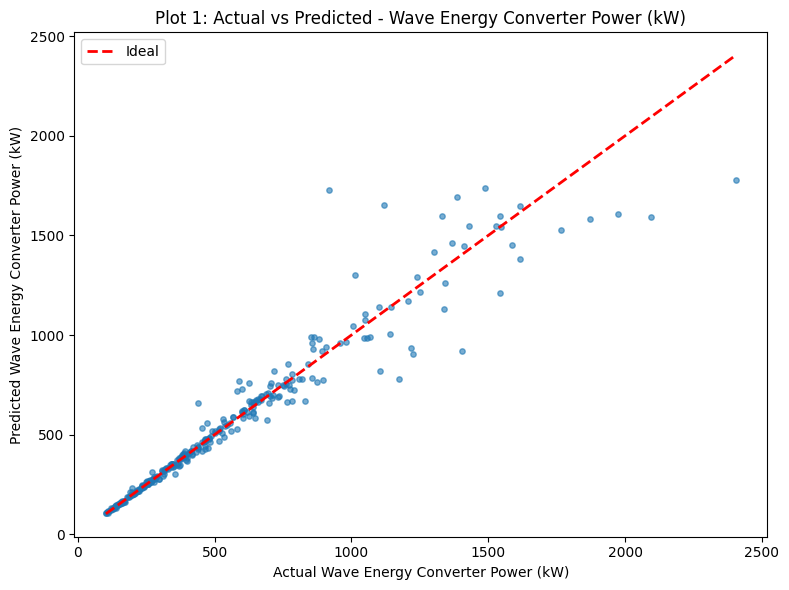

  ✔ Saved: plot_01_actual_vs_pred.png


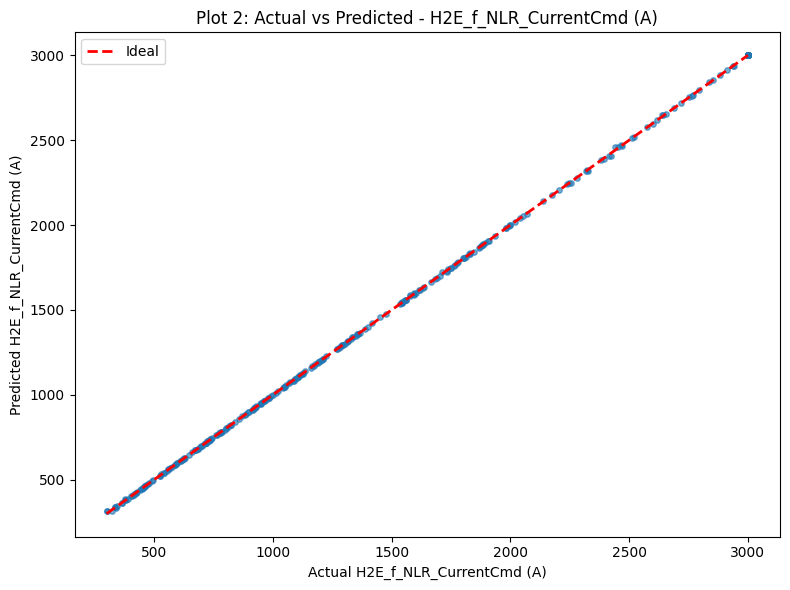

  ✔ Saved: plot_02_actual_vs_pred.png


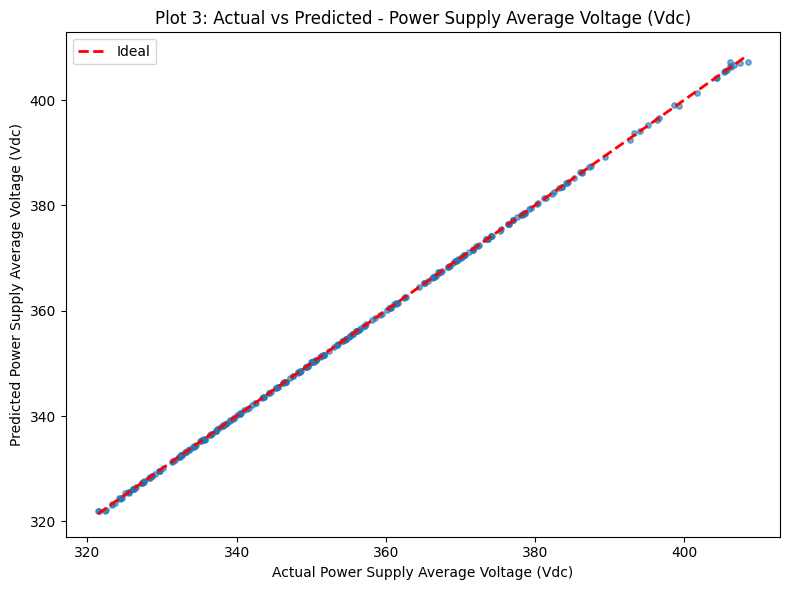

  ✔ Saved: plot_03_actual_vs_pred.png


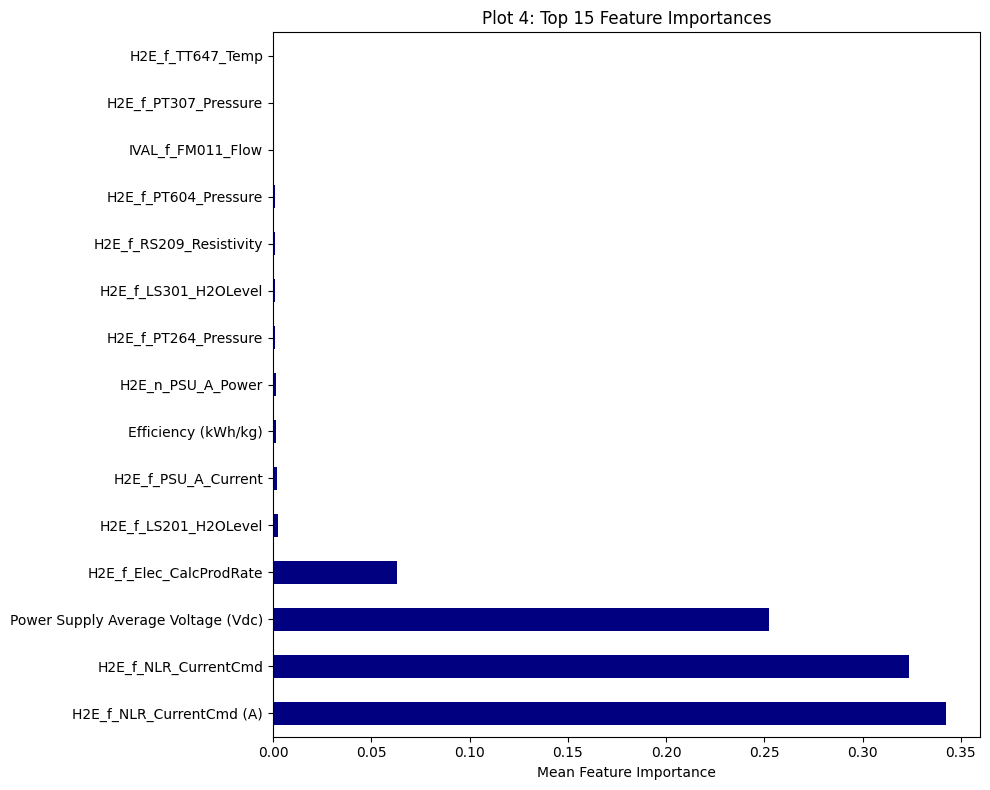

  ✔ Saved: plot_04_feature_importance.png


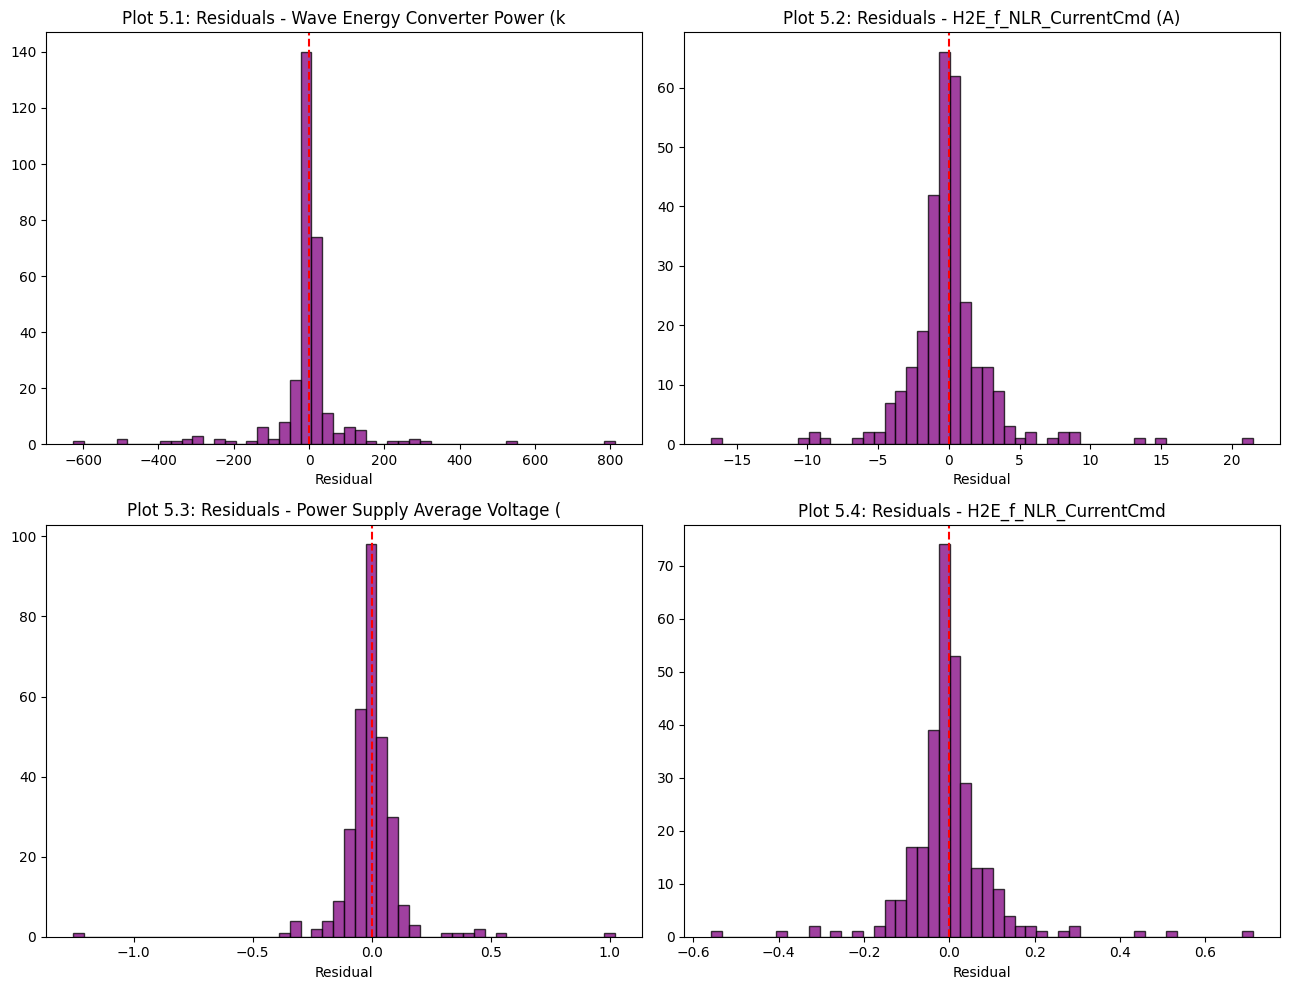

  ✔ Saved: plot_05_residual_histograms.png


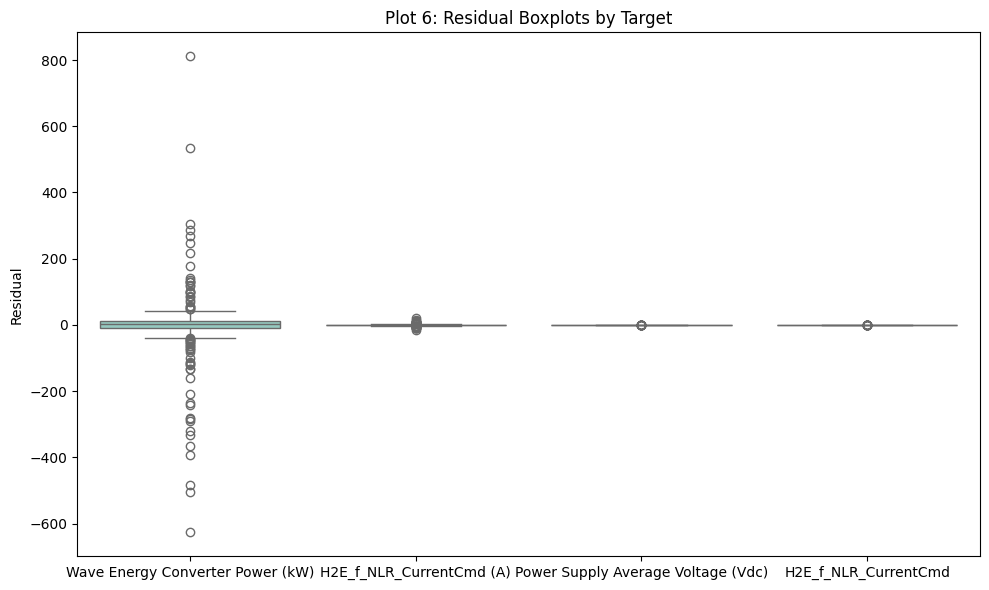

  ✔ Saved: plot_06_residual_boxplots.png


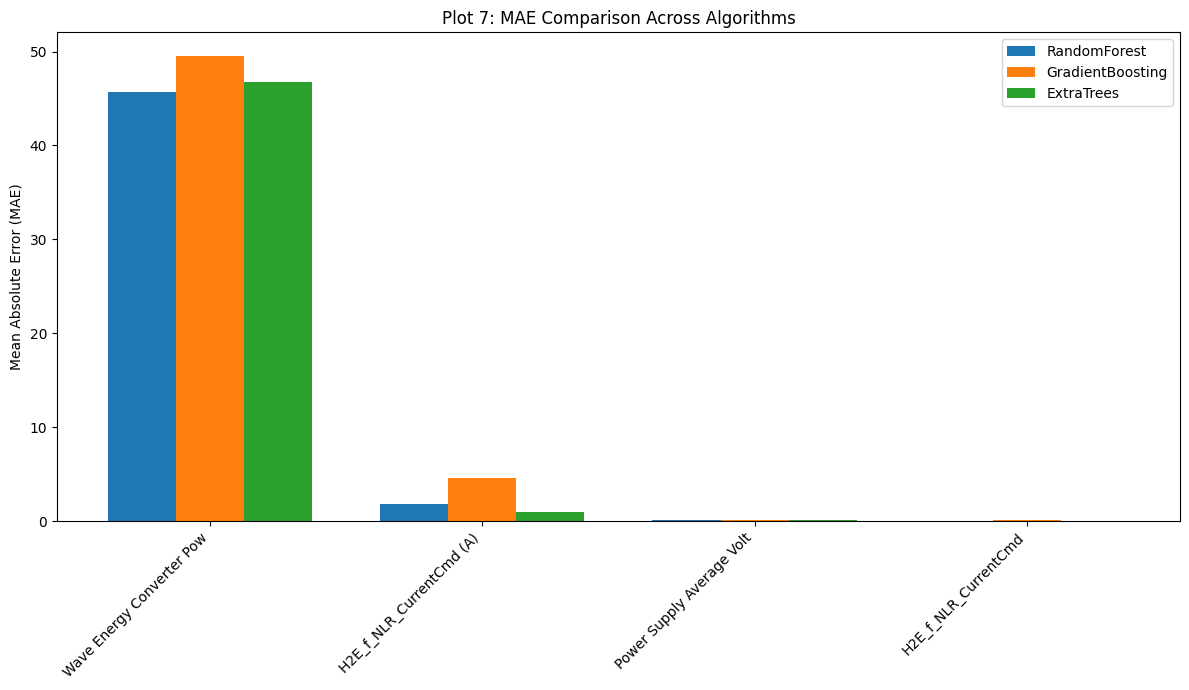

  ✔ Saved: plot_07_mae_comparison.png


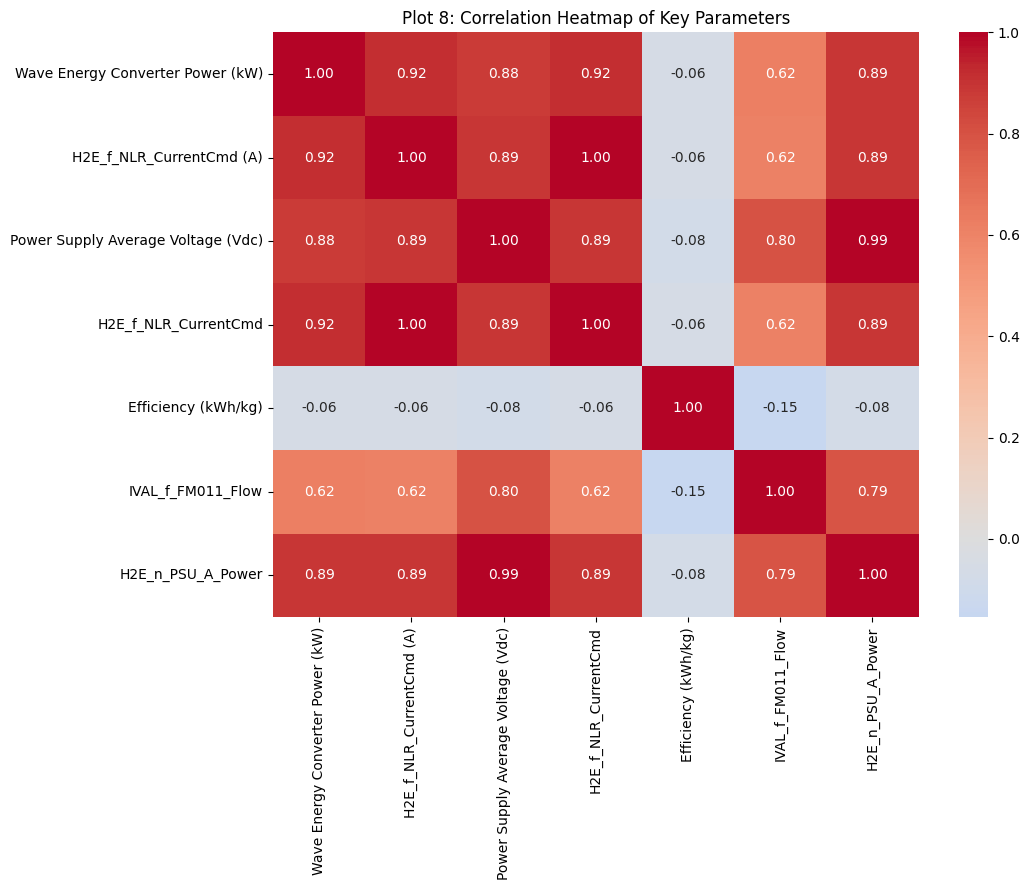

  ✔ Saved: plot_08_correlation_heatmap.png


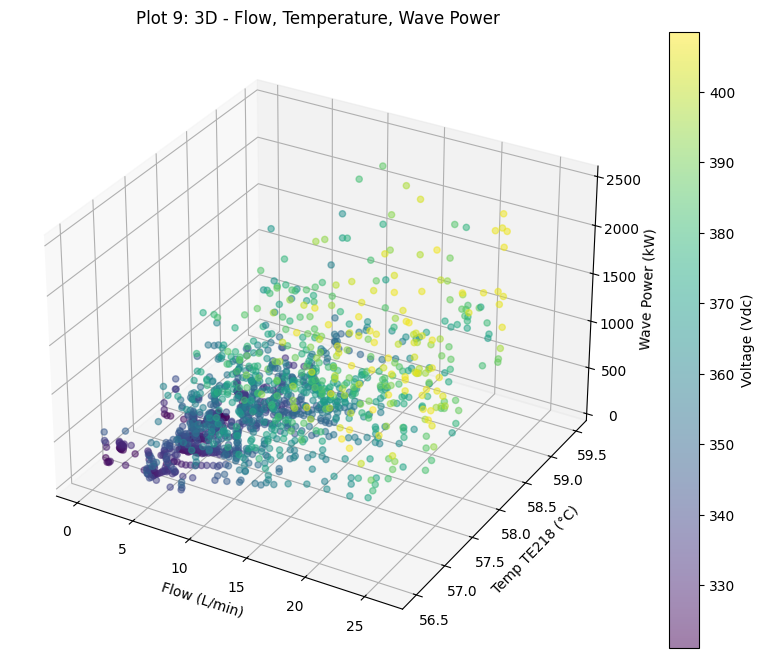

  ✔ Saved: plot_09_3d_flow_temp_power.png


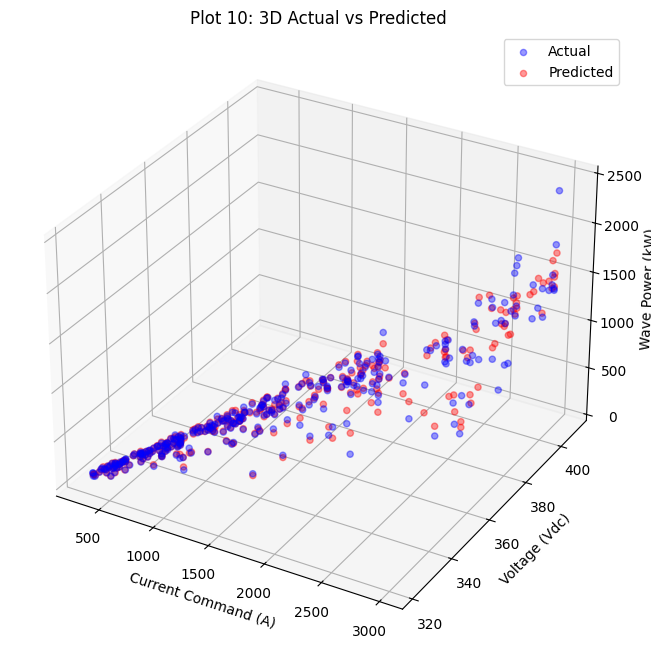

  ✔ Saved: plot_10_3d_actual_vs_pred.png


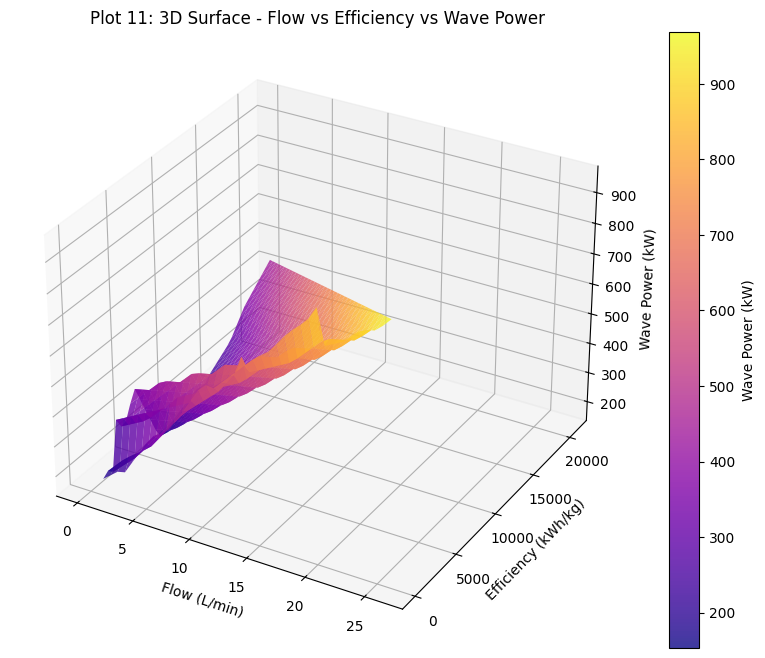

  ✔ Saved: plot_11_3d_surface.png


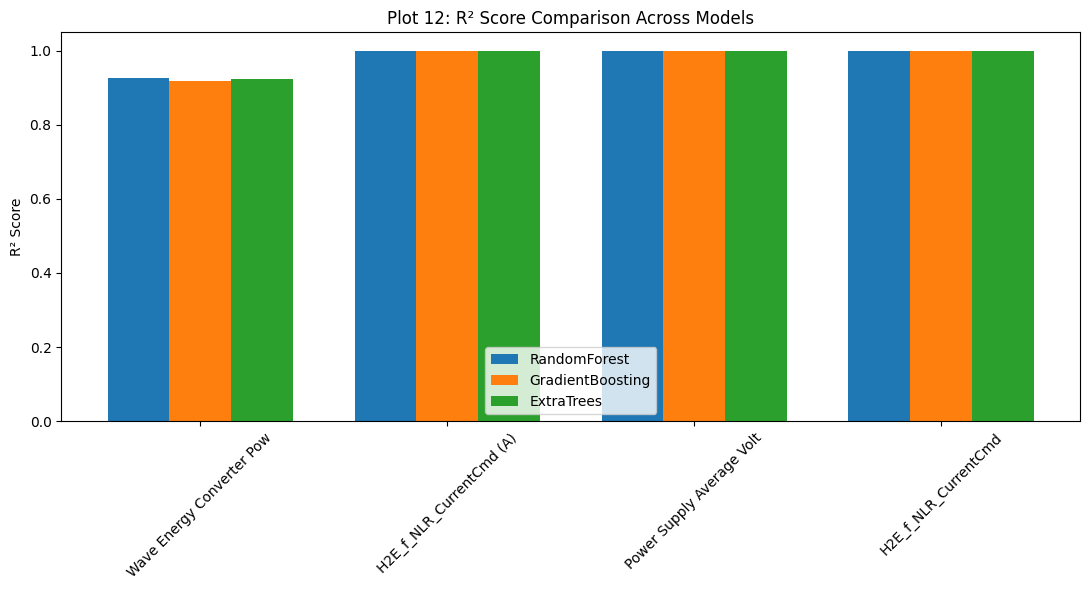

  ✔ Saved: plot_12_r2_comparison.png


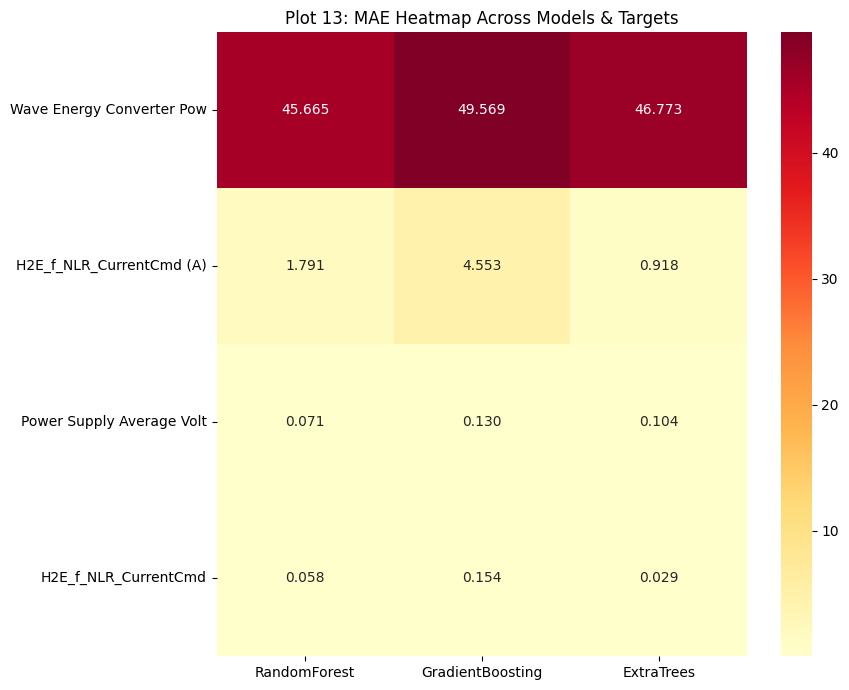

  ✔ Saved: plot_13_mae_heatmap.png


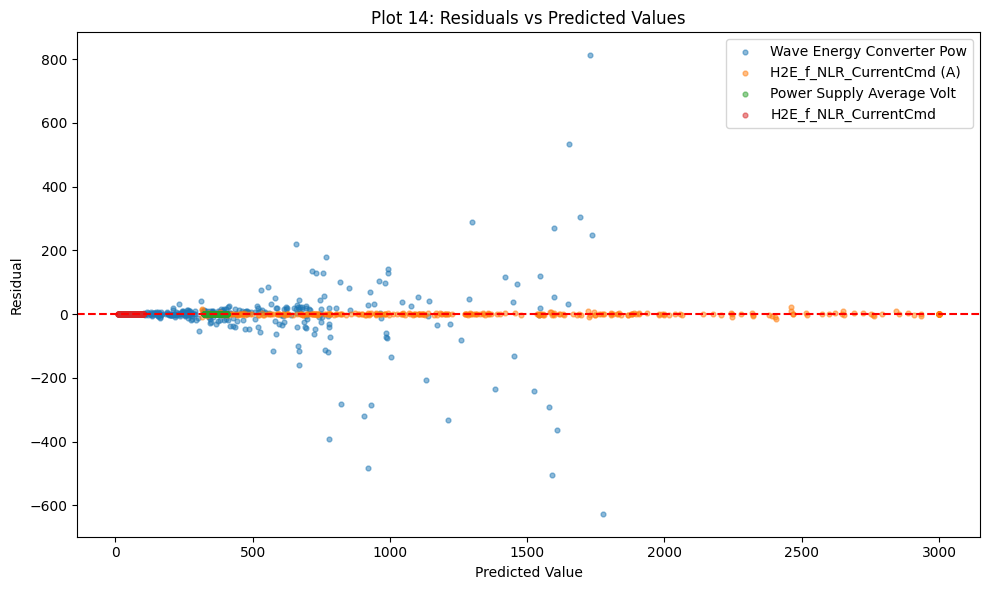

  ✔ Saved: plot_14_residual_vs_predicted.png


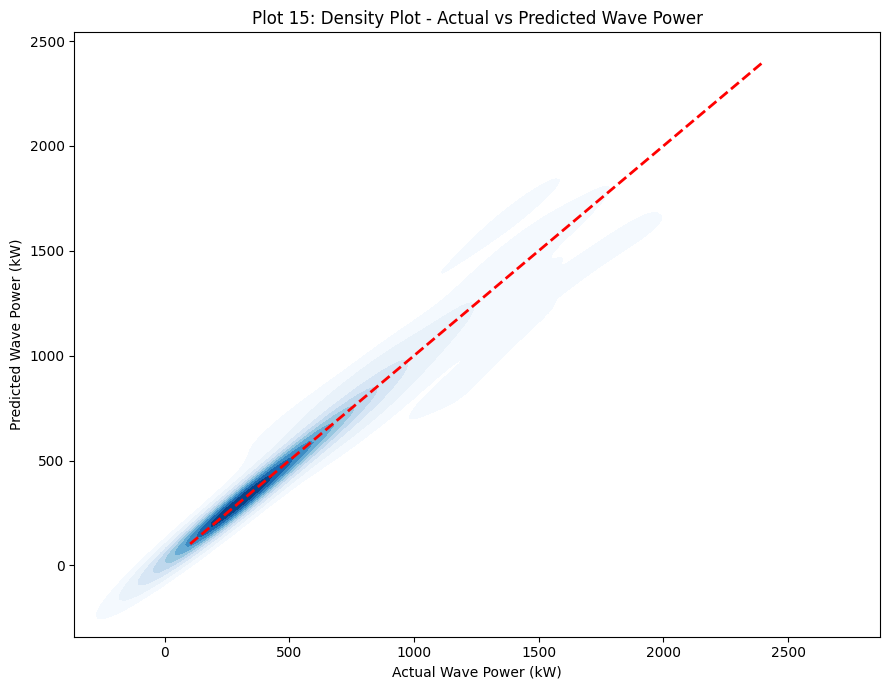

  ✔ Saved: plot_15_density_plot.png

SHAP ANALYSIS  (SHapley Additive exPlanations)
shap already installed.

Computing SHAP values for each target using 300 background samples …


 99%|===================| 299/301 [00:26<00:00]       

  ✔ SHAP values computed for: Wave Energy Converter Power (kW)


 94%|=================== | 284/301 [00:13<00:00]       

  ✔ SHAP values computed for: H2E_f_NLR_CurrentCmd (A)
  ✔ SHAP values computed for: Power Supply Average Voltage (Vdc)


 92%|==================  | 278/301 [00:13<00:01]       

  ✔ SHAP values computed for: H2E_f_NLR_CurrentCmd

Generating SHAP plots …



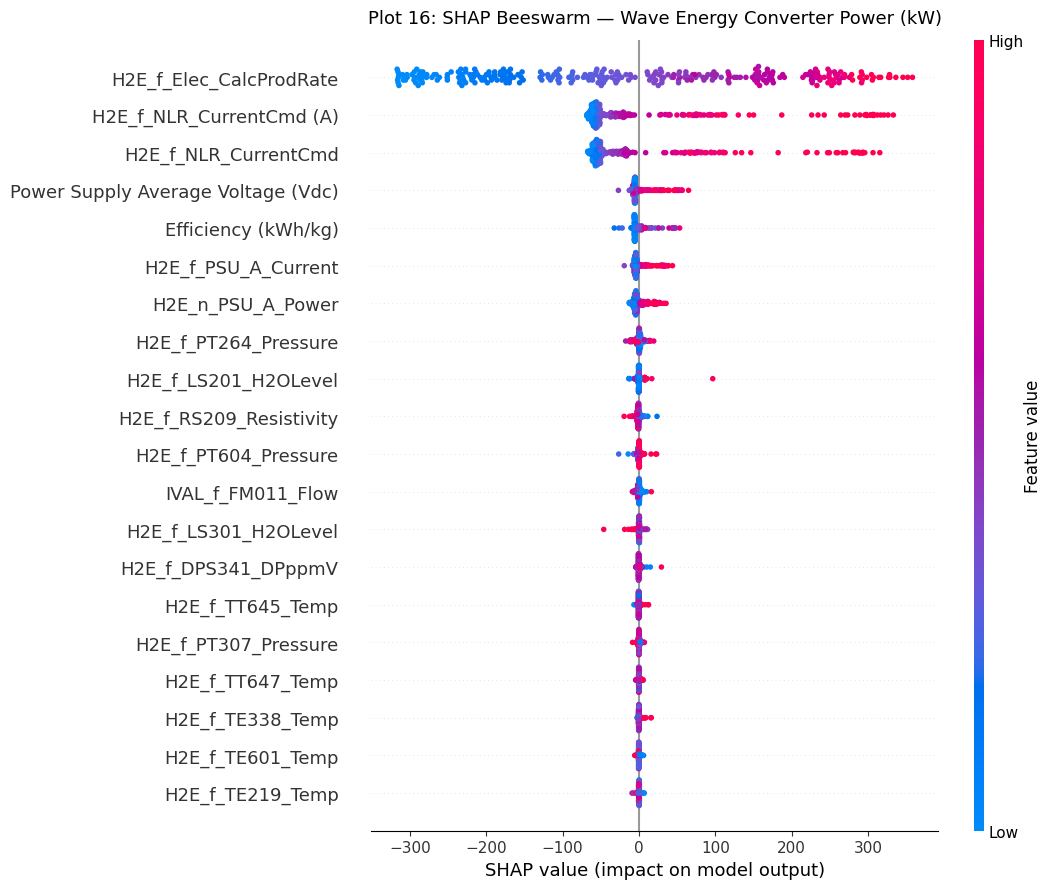

  ✔ Saved: plot_16_shap_beeswarm.png


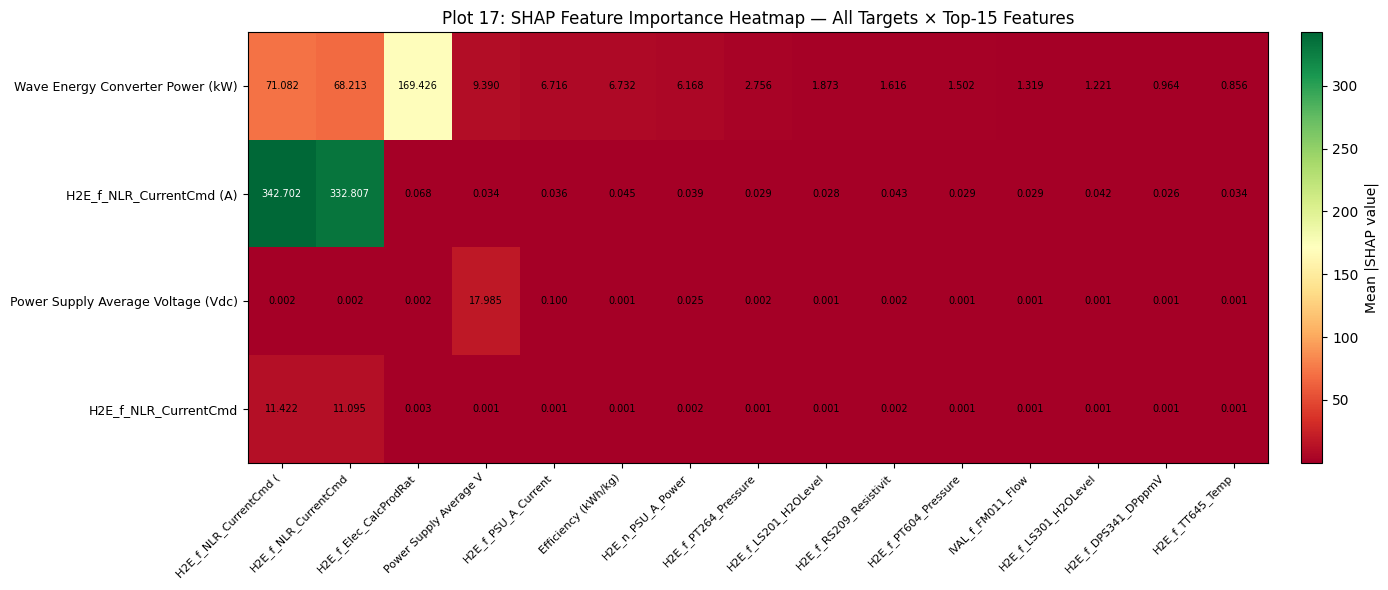

  ✔ Saved: plot_17_shap_importance_heatmap.png


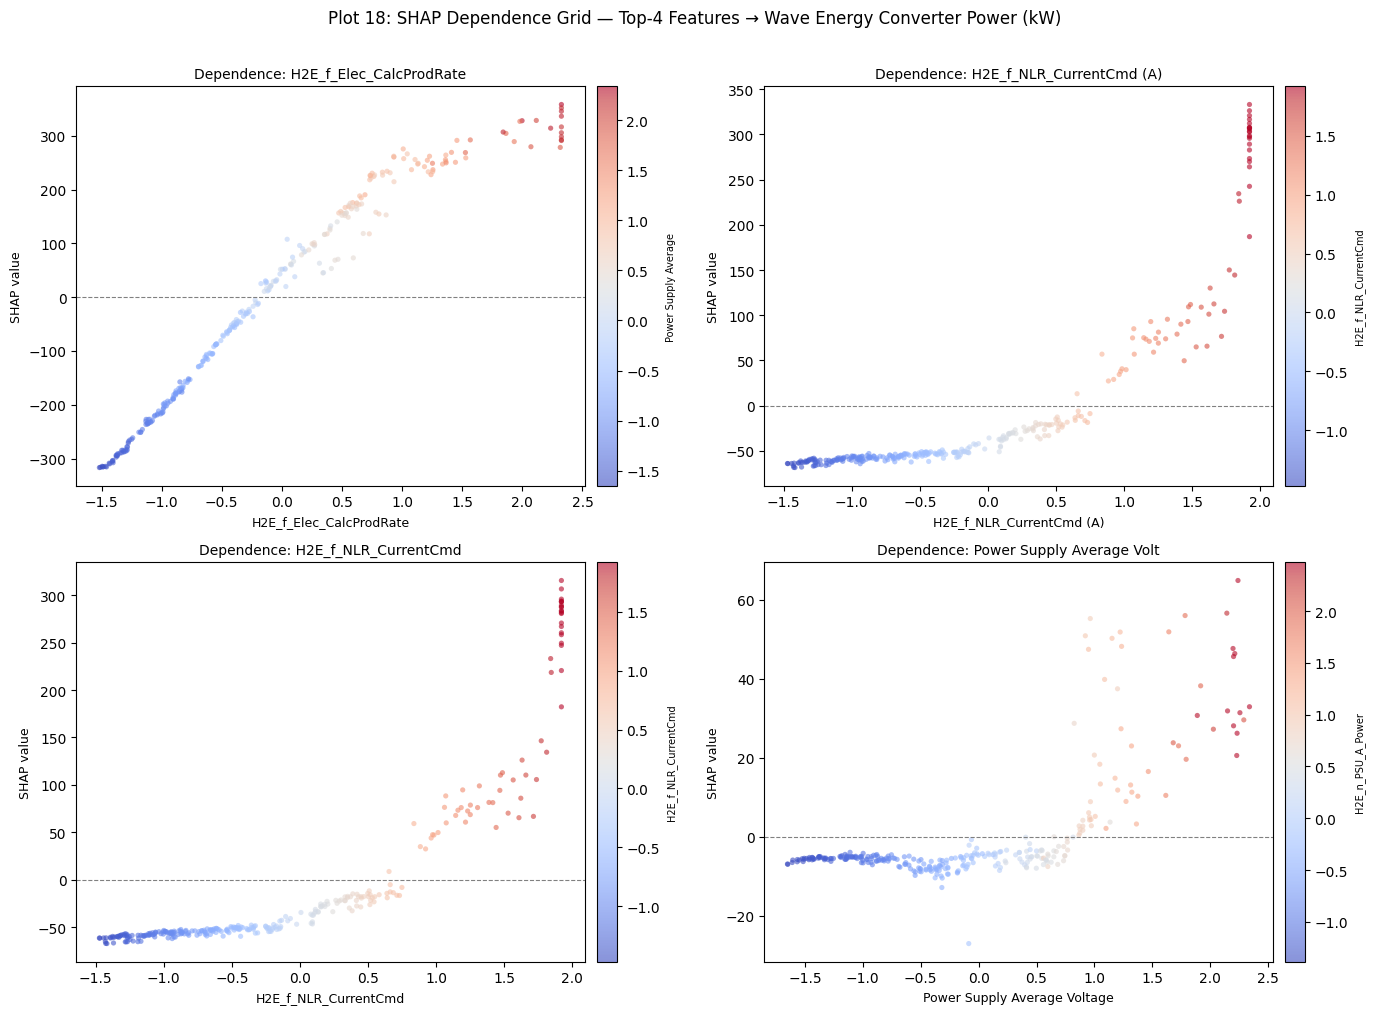

  ✔ Saved: plot_18_shap_dependence_grid.png

SHAP analysis complete — Plots 16, 17, and 18 generated.

All 18 plots displayed above and saved as PNG files.
Run the cell below to download all plots as a ZIP:


from google.colab import files
import zipfile, os

zip_name = 'electrolyzer_plots.zip'
plot_files = sorted([f for f in os.listdir('.') if f.startswith('plot_') and f.endswith('.png')])

with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in plot_files:
        zf.write(f)
        print(f'  Added: {f}')

files.download(zip_name)
print(f'\nDownload triggered: {zip_name}')


Script execution completed successfully!  (15 standard plots + 3 SHAP plots = 18 total)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Enable inline display in Colab/Jupyter
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass  # Not in a notebook environment

print("=== Hydrogen Electrolyzer ML Model with Algorithm Comparison & Enhanced Input ===\n")

# =============================================================================
# 1. LOAD DATA
# =============================================================================
try:
    df = pd.read_csv('dataset.csv')
    df.rename(columns={df.columns[0]: 'Timestamp'}, inplace=True)
    df = df.dropna().reset_index(drop=True)
    print(f"Dataset loaded successfully: {df.shape[0]} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print("ERROR: 'dataset.csv' not found. Please place the file in the same folder.")
    raise

# =============================================================================
# 2. DEFINE TARGETS AND FEATURES
# =============================================================================
TARGET_COLS = [
    'Wave Energy Converter Power (kW)',
    'H2E_f_NLR_CurrentCmd (A)',
    'Power Supply Average Voltage (Vdc)',
    'H2E_f_NLR_CurrentCmd'
]

FEATURE_COLS = [
    'H2E_f_NLR_CurrentCmd (A)', 'IVAL_f_FM011_Flow', 'Efficiency (kWh/kg)',
    'Power Supply Average Voltage (Vdc)', 'H2E_f_NLR_CurrentCmd',
    'H2E_n_PSU_A_Power', 'H2E_f_PSU_A_Current', 'H2E_f_Elec_CalcProdRate',
    'H2E_f_CG220_LFLPer', 'H2E_f_DPS340_DPdegC', 'H2E_f_DPS341_DPdegC',
    'H2E_f_DPS341_DPppmV', 'H2E_f_LS201_H2OLevel', 'H2E_f_LS301_H2OLevel',
    'H2E_f_PT264_Pressure', 'H2E_f_PT307_Pressure', 'H2E_f_PT312_Pressure',
    'H2E_f_PT604_Pressure', 'H2E_f_RS209_Resistivity', 'H2E_f_RS507_Resistivity',
    'H2E_f_TE218_Temp', 'H2E_f_TE219_Temp', 'H2E_f_TE338_Temp',
    'H2E_f_TE601_Temp', 'H2E_f_TT645_Temp', 'H2E_f_TT646_Temp',
    'H2E_f_TT647_Temp', 'H2E_f_TT648_Temp'
]

X = df[FEATURE_COLS]
y = df[TARGET_COLS]

# Calculate statistics for input guidance
means = X.mean()
medians = X.median()
mins = X.min()
maxs = X.max()

print("\nInput Parameter Ranges from Dataset:")
for col in FEATURE_COLS:
    print(f"  {col}:  Min = {mins[col]:.4f}   Max = {maxs[col]:.4f}   Median = {medians[col]:.4f}")

# =============================================================================
# 3. TRAIN-TEST SPLIT & SCALING
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# =============================================================================
# 4. TRAIN MULTIPLE MODELS FOR COMPARISON
# =============================================================================
print("\nTraining models for comparison...")

models = {}
model_names = ['RandomForest', 'GradientBoosting', 'ExtraTrees']

for name in model_names:
    if name == 'RandomForest':
        base = RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)
    elif name == 'GradientBoosting':
        base = GradientBoostingRegressor(n_estimators=250, random_state=42)
    else:
        base = ExtraTreesRegressor(n_estimators=250, random_state=42, n_jobs=-1)

    multi_model = MultiOutputRegressor(base)
    multi_model.fit(X_train_sc, y_train)
    models[name] = multi_model
    print(f"  {name} trained.")

primary_model = models['RandomForest']

# =============================================================================
# 5. MODEL EVALUATION & COMPARISON
# =============================================================================
print("\n" + "="*95)
print("MODEL PERFORMANCE COMPARISON ON TEST SET")
print("="*95)
print(f"{'Model':<18} {'Target':<42} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 95)

results_dict = {}
for name, mdl in models.items():
    y_pred = mdl.predict(X_test_sc)
    for i, col in enumerate(TARGET_COLS):
        mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        print(f"{name:<18} {col:<42} {mae:8.3f} {rmse:8.3f} {r2:8.4f}")
        if col not in results_dict:
            results_dict[col] = {}
        results_dict[col][name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# =============================================================================
# 6. SAVE PRIMARY MODEL
# =============================================================================
joblib.dump(primary_model, 'electrolyzer_model.pkl')
joblib.dump(scaler, 'electrolyzer_scaler.pkl')
print("\nPrimary model and scaler saved.")

# =============================================================================
# 7. INTERACTIVE USER INPUT WITH MIN-MAX RANGE
# =============================================================================
print("\n" + "="*90)
print("ENTER INPUT PARAMETERS")
print("Press Enter to use the median value from the dataset.")
print("="*90)

user_input = {}
prompts = [
    "Wave (A)", "IVAL_f_FM011_Flow", "Efficiency (kWh/kg)",
    "Power Supply Average Voltage (Vdc)", "H2E_f_NLR_CurrentCmd",
    "H2E_n_PSU_A_Power", "H2E_f_PSU_A_Current", "H2E_f_Elec_CalcProdRate",
    "H2E_f_CG220_LFLPer", "H2E_f_DPS340_DPdegC", "H2E_f_DPS341_DPdegC",
    "H2E_f_DPS341_DPppmV", "H2E_f_LS201_H2OLevel", "H2E_f_LS301_H2OLevel",
    "H2E_f_PT264_Pressure", "H2E_f_PT307_Pressure", "H2E_f_PT312_Pressure",
    "H2E_f_PT604_Pressure", "H2E_f_RS209_Resistivity", "H2E_f_RS507_Resistivity",
    "H2E_f_TE218_Temp", "H2E_f_TE219_Temp", "H2E_f_TE338_Temp",
    "H2E_f_TE601_Temp", "H2E_f_TT645_Temp", "H2E_f_TT646_Temp",
    "H2E_f_TT647_Temp", "H2E_f_TT648_Temp"
]

for prompt, col in zip(prompts, FEATURE_COLS):
    min_val = mins[col]
    max_val = maxs[col]
    median_val = medians[col]
    while True:
        try:
            val_str = input(f"  {prompt}  [Range: {min_val:.4f} — {max_val:.4f}]  (Median: {median_val:.4f}): ").strip()
            if val_str == "":
                user_input[col] = median_val
                print(f"    → Using median value: {median_val:.4f}")
            else:
                val = float(val_str)
                if val < min_val or val > max_val:
                    print(f"    Warning: Value is outside the observed range [{min_val:.4f} — {max_val:.4f}]. Still accepted.")
                user_input[col] = val
            break
        except ValueError:
            print("    Invalid input. Please enter a number or press Enter to use median.")

# =============================================================================
# 8. MAKE PREDICTION
# =============================================================================
input_df = pd.DataFrame([user_input], columns=FEATURE_COLS)
input_sc = scaler.transform(input_df)
prediction = primary_model.predict(input_sc)[0]

print("\n" + "="*78)
print("PREDICTION RESULTS")
print("="*78)
for i, col in enumerate(TARGET_COLS):
    print(f"  {col:<48}: {prediction[i]:.4f}")
print("="*78)

# =============================================================================
# 9. GENERATE 15+ PLOTS  (inline display + file save)
# =============================================================================
print("\nGenerating 15+ visualization plots...\n")

actual_test = y_test.reset_index(drop=True)
pred_test = pd.DataFrame(primary_model.predict(X_test_sc), columns=TARGET_COLS)

def save_and_show(filename, title=""):
    """Save figure to disk AND display it inline in Colab/Jupyter."""
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()          # ← renders the plot inline in the notebook
    plt.close()
    print(f"  ✔ Saved: {filename}")

# --- Plots 1-3: Actual vs Predicted ---
for i, col in enumerate(TARGET_COLS[:3]):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(actual_test[col], pred_test[col], alpha=0.6, s=15)
    minv = min(actual_test[col].min(), pred_test[col].min())
    maxv = max(actual_test[col].max(), pred_test[col].max())
    ax.plot([minv, maxv], [minv, maxv], 'r--', lw=2, label='Ideal')
    ax.set_xlabel(f'Actual {col}')
    ax.set_ylabel(f'Predicted {col}')
    ax.set_title(f'Plot {i+1}: Actual vs Predicted - {col}')
    ax.legend()
    plt.tight_layout()
    save_and_show(f'plot_{i+1:02d}_actual_vs_pred.png')

# --- Plot 4: Feature Importance ---
importances = np.mean([est.feature_importances_ for est in primary_model.estimators_], axis=0)
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color='navy')
ax.set_xlabel('Mean Feature Importance')
ax.set_title('Plot 4: Top 15 Feature Importances')
plt.tight_layout()
save_and_show('plot_04_feature_importance.png')

# --- Plot 5: Residual Histograms ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
for i, col in enumerate(TARGET_COLS):
    residuals = pred_test[col] - actual_test[col]
    axes[i].hist(residuals, bins=50, alpha=0.75, color='purple', edgecolor='black')
    axes[i].axvline(0, color='red', linestyle='--')
    axes[i].set_title(f'Plot 5.{i+1}: Residuals - {col[:30]}')
    axes[i].set_xlabel('Residual')
plt.tight_layout()
save_and_show('plot_05_residual_histograms.png')

# --- Plot 6: Residual Boxplot ---
residuals_df = pd.DataFrame({col: pred_test[col] - actual_test[col] for col in TARGET_COLS})
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=residuals_df, ax=ax, palette="Set3")
ax.set_title('Plot 6: Residual Boxplots by Target')
ax.set_ylabel('Residual')
plt.tight_layout()
save_and_show('plot_06_residual_boxplots.png')

# --- Plot 7: MAE Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(TARGET_COLS))
width = 0.25
for idx, name in enumerate(model_names):
    maes = [results_dict[col][name]['MAE'] for col in TARGET_COLS]
    ax.bar(x + idx*width, maes, width, label=name)
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.set_title('Plot 7: MAE Comparison Across Algorithms')
ax.set_xticks(x + width)
ax.set_xticklabels([col[:25] for col in TARGET_COLS], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
save_and_show('plot_07_mae_comparison.png')

# --- Plot 8: Correlation Heatmap ---
key_cols = TARGET_COLS + ['Efficiency (kWh/kg)', 'IVAL_f_FM011_Flow', 'H2E_n_PSU_A_Power']
corr = df[key_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Plot 8: Correlation Heatmap of Key Parameters')
plt.tight_layout()
save_and_show('plot_08_correlation_heatmap.png')

# --- Plot 9: 3D Scatter ---
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['IVAL_f_FM011_Flow'], df['H2E_f_TE218_Temp'],
                df['Wave Energy Converter Power (kW)'],
                c=df['Power Supply Average Voltage (Vdc)'], cmap='viridis', alpha=0.5)
fig.colorbar(sc, label='Voltage (Vdc)')
ax.set_xlabel('Flow (L/min)')
ax.set_ylabel('Temp TE218 (°C)')
ax.set_zlabel('Wave Power (kW)')
ax.set_title('Plot 9: 3D - Flow, Temperature, Wave Power')
save_and_show('plot_09_3d_flow_temp_power.png')

# --- Plot 10: 3D Actual vs Predicted ---
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(actual_test['H2E_f_NLR_CurrentCmd (A)'], actual_test['Power Supply Average Voltage (Vdc)'],
           actual_test['Wave Energy Converter Power (kW)'], color='blue', alpha=0.4, label='Actual')
ax.scatter(pred_test['H2E_f_NLR_CurrentCmd (A)'], pred_test['Power Supply Average Voltage (Vdc)'],
           pred_test['Wave Energy Converter Power (kW)'], color='red', alpha=0.4, label='Predicted')
ax.set_xlabel('Current Command (A)')
ax.set_ylabel('Voltage (Vdc)')
ax.set_zlabel('Wave Power (kW)')
ax.set_title('Plot 10: 3D Actual vs Predicted')
ax.legend()
save_and_show('plot_10_3d_actual_vs_pred.png')

# --- Plot 11: 3D Surface ---
from scipy.interpolate import griddata
flow = df['IVAL_f_FM011_Flow'].values
eff  = df['Efficiency (kWh/kg)'].values
power = df['Wave Energy Converter Power (kW)'].values
xi = np.linspace(flow.min(), flow.max(), 40)
yi = np.linspace(eff.min(), eff.max(), 40)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((flow, eff), power, (xi, yi), method='linear')

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xi, yi, zi, cmap='plasma', alpha=0.8)
fig.colorbar(surf, label='Wave Power (kW)')
ax.set_xlabel('Flow (L/min)')
ax.set_ylabel('Efficiency (kWh/kg)')
ax.set_zlabel('Wave Power (kW)')
ax.set_title('Plot 11: 3D Surface - Flow vs Efficiency vs Wave Power')
save_and_show('plot_11_3d_surface.png')

# --- Plot 12: R² Comparison ---
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(TARGET_COLS))
for i, name in enumerate(model_names):
    r2s = [results_dict[col][name]['R2'] for col in TARGET_COLS]
    ax.bar(x + i*0.25, r2s, 0.25, label=name)
ax.set_ylabel('R² Score')
ax.set_title('Plot 12: R² Score Comparison Across Models')
ax.set_xticks(x + 0.25)
ax.set_xticklabels([c[:25] for c in TARGET_COLS], rotation=45)
ax.legend()
plt.tight_layout()
save_and_show('plot_12_r2_comparison.png')

# --- Plot 13: MAE Heatmap ---
mae_matrix = np.array([[results_dict[col][name]['MAE'] for name in model_names] for col in TARGET_COLS])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mae_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=model_names, yticklabels=[c[:25] for c in TARGET_COLS], ax=ax)
ax.set_title('Plot 13: MAE Heatmap Across Models & Targets')
plt.tight_layout()
save_and_show('plot_13_mae_heatmap.png')

# --- Plot 14: Residuals vs Predicted ---
fig, ax = plt.subplots(figsize=(10, 6))
for col in TARGET_COLS:
    res = pred_test[col] - actual_test[col]
    ax.scatter(pred_test[col], res, alpha=0.5, s=12, label=col[:25])
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Residual')
ax.set_title('Plot 14: Residuals vs Predicted Values')
ax.legend()
plt.tight_layout()
save_and_show('plot_14_residual_vs_predicted.png')

# --- Plot 15: Density Plot ---
fig, ax = plt.subplots(figsize=(9, 7))
sns.kdeplot(x=actual_test['Wave Energy Converter Power (kW)'],
            y=pred_test['Wave Energy Converter Power (kW)'],
            fill=True, cmap='Blues', ax=ax)
minv = actual_test['Wave Energy Converter Power (kW)'].min()
maxv = actual_test['Wave Energy Converter Power (kW)'].max()
ax.plot([minv, maxv], [minv, maxv], 'r--', lw=2)
ax.set_xlabel('Actual Wave Power (kW)')
ax.set_ylabel('Predicted Wave Power (kW)')
ax.set_title('Plot 15: Density Plot - Actual vs Predicted Wave Power')
plt.tight_layout()
save_and_show('plot_15_density_plot.png')

# =============================================================================
# 10. SHAP ANALYSIS
# =============================================================================
print("\n" + "="*90)
print("SHAP ANALYSIS  (SHapley Additive exPlanations)")
print("="*90)

# Install shap if not present (Colab-safe)
try:
    import shap
    print("shap already installed.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("shap installed successfully.")

# ── Use a background sample for speed (TreeExplainer works on the underlying
#    RandomForest estimators, one per target output) ──────────────────────────
SHAP_SAMPLE = min(300, X_train_sc.shape[0])
background  = shap.sample(pd.DataFrame(X_train_sc, columns=FEATURE_COLS), SHAP_SAMPLE)

print(f"\nComputing SHAP values for each target using {SHAP_SAMPLE} background samples …")

shap_values_per_target = []   # list of 2-D arrays  [n_test × n_features]
for t_idx, t_col in enumerate(TARGET_COLS):
    estimator = primary_model.estimators_[t_idx]   # underlying RandomForestRegressor
    explainer  = shap.TreeExplainer(estimator, data=background, feature_perturbation='interventional')
    sv = explainer.shap_values(pd.DataFrame(X_test_sc, columns=FEATURE_COLS))
    shap_values_per_target.append(sv)
    print(f"  ✔ SHAP values computed for: {t_col}")

# ── Mean |SHAP| per feature per target ──────────────────────────────────────
mean_abs_shap = np.array([np.abs(sv).mean(axis=0) for sv in shap_values_per_target])
# shape: (n_targets × n_features)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 16 — SHAP Summary Beeswarm  (target = Wave Energy Converter Power)
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating SHAP plots …\n")

primary_target_idx = 0   # 'Wave Energy Converter Power (kW)'
primary_target_name = TARGET_COLS[primary_target_idx]

fig, ax = plt.subplots(figsize=(11, 9))
shap.summary_plot(
    shap_values_per_target[primary_target_idx],
    pd.DataFrame(X_test_sc, columns=FEATURE_COLS),
    feature_names=FEATURE_COLS,
    plot_type="dot",        # classic beeswarm
    max_display=20,
    show=False,
    plot_size=None
)
plt.title(f'Plot 16: SHAP Beeswarm — {primary_target_name}', fontsize=13, pad=12)
plt.tight_layout()
save_and_show('plot_16_shap_beeswarm.png')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 17 — SHAP Mean |Value| Heatmap  (all targets × top-15 features)
# Shows which features drive each output and lets you compare targets side-by-side
# ─────────────────────────────────────────────────────────────────────────────

# Rank features by their total importance across all targets
total_importance = mean_abs_shap.sum(axis=0)
top15_idx  = np.argsort(total_importance)[::-1][:15]
top15_names = [FEATURE_COLS[i] for i in top15_idx]

shap_heatmap_data = mean_abs_shap[:, top15_idx]   # (n_targets × 15)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(shap_heatmap_data, aspect='auto', cmap='RdYlGn')
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.03)
cbar.set_label('Mean |SHAP value|', fontsize=10)

ax.set_xticks(range(15))
ax.set_xticklabels([n[:22] for n in top15_names], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(TARGET_COLS)))
ax.set_yticklabels([c[:35] for c in TARGET_COLS], fontsize=9)
ax.set_title('Plot 17: SHAP Feature Importance Heatmap — All Targets × Top-15 Features', fontsize=12)

# Annotate cells with values
for r in range(len(TARGET_COLS)):
    for c in range(15):
        ax.text(c, r, f'{shap_heatmap_data[r, c]:.3f}',
                ha='center', va='center', fontsize=7,
                color='black' if shap_heatmap_data[r, c] < shap_heatmap_data.max()*0.7 else 'white')

plt.tight_layout()
save_and_show('plot_17_shap_importance_heatmap.png')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 18 — SHAP Dependence Plot Grid  (top-4 features for primary target)
# Each panel shows how feature value drives the SHAP contribution, coloured by
# the most-interacting feature (auto-detected by SHAP)
# ─────────────────────────────────────────────────────────────────────────────
top4_idx = np.argsort(mean_abs_shap[primary_target_idx])[::-1][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
X_test_df = pd.DataFrame(X_test_sc, columns=FEATURE_COLS)

for panel, feat_idx in enumerate(top4_idx):
    feat_name = FEATURE_COLS[feat_idx]
    sv_col    = shap_values_per_target[primary_target_idx][:, feat_idx]

    # Find the automatically chosen interaction feature (highest |corr| with residual)
    residuals_shap = shap_values_per_target[primary_target_idx] - sv_col[:, None]
    corr_with_others = np.abs(np.corrcoef(sv_col, X_test_sc.T)[0, 1:])
    corr_with_others[feat_idx] = -1   # exclude self
    interact_idx = int(np.argmax(corr_with_others))
    interact_name = FEATURE_COLS[interact_idx]

    sc = axes[panel].scatter(
        X_test_df[feat_name], sv_col,
        c=X_test_df[interact_name], cmap='coolwarm',
        alpha=0.6, s=14, edgecolors='none'
    )
    cb = fig.colorbar(sc, ax=axes[panel], pad=0.02)
    cb.set_label(interact_name[:20], fontsize=7)
    axes[panel].axhline(0, color='grey', linestyle='--', linewidth=0.8)
    axes[panel].set_xlabel(feat_name[:28], fontsize=9)
    axes[panel].set_ylabel('SHAP value', fontsize=9)
    axes[panel].set_title(f'Dependence: {feat_name[:25]}', fontsize=10)

fig.suptitle(f'Plot 18: SHAP Dependence Grid — Top-4 Features → {primary_target_name}',
             fontsize=12, y=1.01)
plt.tight_layout()
save_and_show('plot_18_shap_dependence_grid.png')

print("\nSHAP analysis complete — Plots 16, 17, and 18 generated.")

# =============================================================================
# 11. DOWNLOAD ALL PLOT FILES (Colab helper)
# =============================================================================
print("\n" + "="*60)
print("All 18 plots displayed above and saved as PNG files.")
print("Run the cell below to download all plots as a ZIP:\n")
print("""
from google.colab import files
import zipfile, os

zip_name = 'electrolyzer_plots.zip'
plot_files = sorted([f for f in os.listdir('.') if f.startswith('plot_') and f.endswith('.png')])

with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in plot_files:
        zf.write(f)
        print(f'  Added: {f}')

files.download(zip_name)
print(f'\\nDownload triggered: {zip_name}')
""")
print("="*60)
print("\nScript execution completed successfully!  (15 standard plots + 3 SHAP plots = 18 total)")